In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [70]:
file_path = './data/T22024-10-23-14-0.xlsx'  # Excel 文件路径
data = pd.read_excel(file_path, usecols=['x', 'y'],sheet_name='data')

In [71]:
x_data = np.array(data['x'].tolist())
y_data = np.array(data['y'].tolist())

In [72]:
# 定义要拟合的非线性函数
def nonlinear_func(x, A, a, T, B):
    return A * np.exp(-(x/T)**a) + B

In [75]:
# 使用curve_fit进行拟合
initial_guess = [10, 10, 10000, -2] 
popt, pcov = curve_fit(nonlinear_func, x_data, y_data, p0=initial_guess)

# 提取拟合参数
A_fit, a_fit, T_fit, B_fit = popt
popt

array([ 1.05513906e+00,  2.21611725e+00,  1.05785751e+04, -4.06965297e+00])

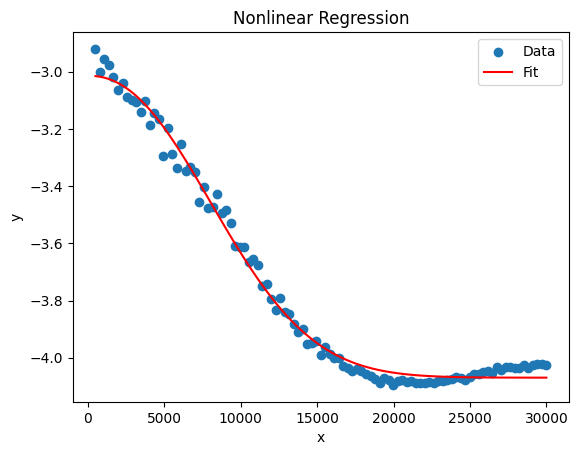

In [76]:
# 根据拟合参数生成拟合曲线的x值
x_fit = np.linspace(min(x_data), max(x_data), 100)

# 计算拟合曲线的y值
y_fit = nonlinear_func(x_fit,A_fit, a_fit, T_fit, B_fit)

# 绘制原始散点和拟合曲线
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_fit, y_fit, 'r', label='Fit')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Nonlinear Regression')

# 显示图形
plt.show()

In [79]:
y_pred = nonlinear_func(x_data, *popt)
# 计算 R^2
ss_res = np.sum((y_data - y_pred) ** 2)  # 残差平方和
ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)  # 总平方和
r_squared = 1 - (ss_res / ss_tot)
print("R^2:", r_squared)

R^2: 0.9921513332676608
